In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


(50000, 32, 32, 3)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
X_train.shape

(50000, 32, 32, 3)

In [ ]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [ ]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [ ]:
y_test = y_test.reshape(-1,)

In [ ]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

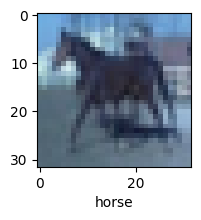

In [ ]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])
plot_sample(X_train, y_train, 499)

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
cnn.fit(X_train, y_train, epochs=20)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7785 - loss: 0.6352
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7911 - loss: 0.5992
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7984 - loss: 0.5735
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8081 - loss: 0.5479
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8218 - loss: 0.5145
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8278 - loss: 0.4911
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8381 - loss: 0.4618
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8425 - loss: 0.4440
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8524 - loss: 0.4195
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8586 - loss: 0.3980
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8670 - loss: 0.3739
Epoch 12/20
1563/1563 ━━━━━━━

In [ ]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6684 - loss: 1.7319


[1.7319269180297852, 0.66839998960495]

In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[3.9195903e-03, 2.9274623e-04, 6.4037164e-04, 7.7660716e-01,
        5.5873976e-04, 1.9035453e-01, 3.7959132e-03, 2.5063709e-03,
        1.8773321e-02, 2.5511619e-03],
       [5.0917152e-02, 6.8910915e-01, 1.3498477e-05, 2.2900222e-06,
        1.0153406e-06, 1.1023404e-08, 6.9487673e-09, 4.9301054e-08,
        2.5250053e-01, 7.4562985e-03],
       [1.0321711e-01, 3.9862427e-01, 1.9613572e-03, 1.3624897e-02,
        1.7601156e-03, 6.2086282e-04, 5.4546120e-04, 6.6133059e-04,
        4.0245786e-01, 7.6526739e-02],
       [9.3392646e-01, 4.1780606e-02, 1.0167487e-02, 1.0587977e-03,
        1.6913133e-03, 2.2543422e-06, 6.8417234e-05, 1.5243865e-05,
        1.1229884e-02, 5.9449012e-05],
       [4.2112015e-06, 1.2618529e-04, 3.1545755e-02, 5.0433666e-02,
        6.5176773e-01, 3.9420198e-03, 2.6189074e-01, 2.7549497e-04,
        1.3401587e-05, 7.8520100e-07]], dtype=float32)

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(1), np.int64(8), np.int64(0), np.int64(4)]

In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

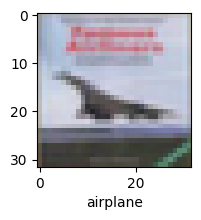

In [ ]:
plot_sample(X_test, y_test,3)


In [ ]:
classes[y_classes[3]]

'airplane'

### Addressing Overfitting: Data Augmentation and Dropout

To combat overfitting, we'll first implement **Data Augmentation** to create more diverse training examples from our existing data. Then, we'll modify the CNN model to include **Dropout layers**, which help prevent the network from relying too heavily on any single feature.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create a data augmentation generator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    zoom_range=0.1
)

# Prepare iterator
datagen.fit(X_train)

print("Data augmentation generator created and fitted.")

Data augmentation generator created and fitted.


Now, let's redefine the CNN model to include Dropout layers. Dropout helps prevent neurons from co-adapting too much during training, encouraging them to learn more robust features.

In [ ]:
cnn_augmented = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Added Dropout

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Added Dropout

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Added Dropout
    layers.Dense(10, activation='softmax')
])

cnn_augmented.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Augmented CNN model defined and compiled.")

Augmented CNN model defined and compiled.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Now we will train the new model using the data augmentation generator. We will use `datagen.flow()` with `fit()`.

In [ ]:
cnn_augmented.fit(datagen.flow(X_train, y_train, batch_size=32),
                    epochs=10, # Increased epochs to allow more training with augmented data
                    validation_data=(X_test, y_test))

print("Augmented CNN model training complete.")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.4817 - loss: 1.4329 - val_accuracy: 0.5896 - val_loss: 1.1645
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.4995 - loss: 1.3975 - val_accuracy: 0.6132 - val_loss: 1.1134
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5057 - loss: 1.3748 - val_accuracy: 0.6082 - val_loss: 1.1087
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5151 - loss: 1.3578 - val_accuracy: 0.5921 - val_loss: 1.1307
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5197 - loss: 1.3454 - val_accuracy: 0.6232 - val_loss: 1.0940
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5242 - loss: 1.3315 - val_accuracy: 0.6371 - val_loss: 1.0528
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.5322 - loss: 1.3154 - val_accuracy: 0.6269 - val_loss: 1.0579
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5342 -

Finally, let's evaluate the performance of the augmented model on the test set.

In [ ]:
print("Evaluating augmented CNN model...")
cnn_augmented.evaluate(X_test, y_test)

Evaluating augmented CNN model...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6530 - loss: 1.0123


[1.0122922658920288, 0.652999997138977]

### Confusion Matrix and Classification Report

Let's generate a confusion matrix and classification report to evaluate the performance of the `cnn_augmented` model in more detail. This will show us how well the model is classifying each specific class.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


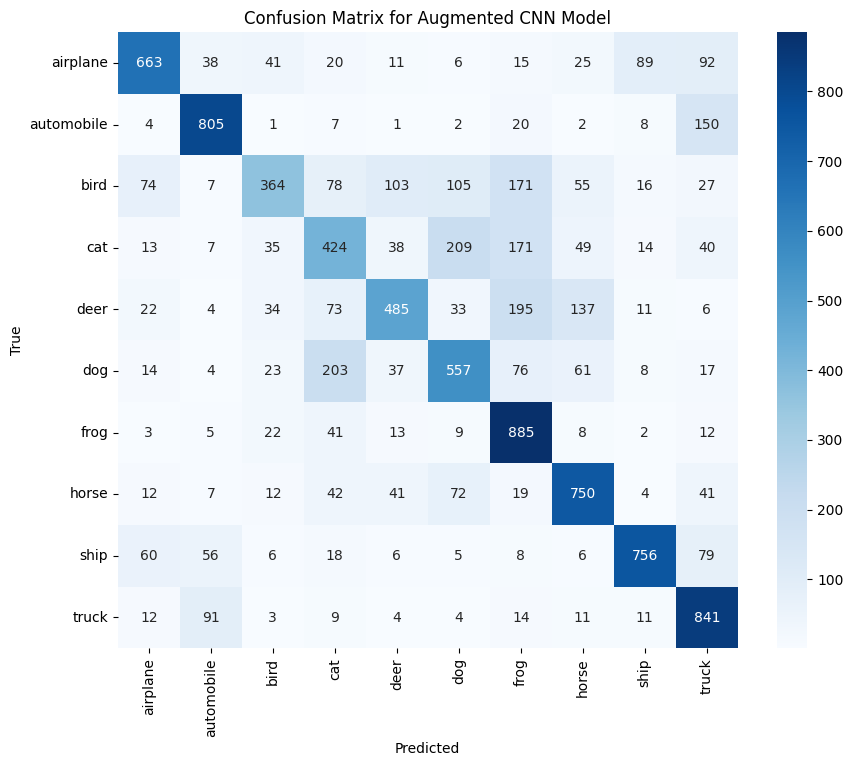

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions for the test set from the augmented model
y_pred_augmented = cnn_augmented.predict(X_test)
y_classes_augmented = [np.argmax(element) for element in y_pred_augmented]

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_classes_augmented)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Augmented CNN Model')
plt.show()

In [ ]:
print("Classification Report for Augmented CNN Model:")
print(classification_report(y_test, y_classes_augmented, target_names=classes))

Classification Report for Augmented CNN Model:
              precision    recall  f1-score   support

    airplane       0.76      0.66      0.71      1000
  automobile       0.79      0.81      0.80      1000
        bird       0.67      0.36      0.47      1000
         cat       0.46      0.42      0.44      1000
        deer       0.66      0.48      0.56      1000
         dog       0.56      0.56      0.56      1000
        frog       0.56      0.89      0.69      1000
       horse       0.68      0.75      0.71      1000
        ship       0.82      0.76      0.79      1000
       truck       0.64      0.84      0.73      1000

    accuracy                           0.65     10000
   macro avg       0.66      0.65      0.64     10000
weighted avg       0.66      0.65      0.64     10000



In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[3.48555531e-08, 3.23532277e-11, 1.74286585e-09, 9.98320162e-01,
        1.00169835e-07, 1.67538703e-03, 1.65003303e-06, 3.83024314e-07,
        2.20623679e-06, 1.36816780e-10],
       [7.39014195e-06, 4.40597243e-04, 3.44014487e-12, 7.99707739e-13,
        2.38996952e-12, 1.96662315e-18, 2.28042305e-21, 2.62450450e-18,
        9.99546468e-01, 5.46006822e-06],
       [8.76087919e-02, 5.40777994e-03, 2.65360177e-06, 2.42663169e-04,
        2.70265332e-06, 6.62505215e-07, 6.03675865e-09, 2.00324507e-07,
        9.06339109e-01, 3.95443989e-04],
       [9.64099765e-01, 4.88969931e-08, 2.84903740e-06, 5.21864495e-05,
        1.32380745e-10, 1.74790799e-19, 1.63343326e-15, 8.41114040e-17,
        3.58451866e-02, 5.82810601e-13],
       [6.55551308e-12, 2.87054513e-06, 7.80859441e-02, 7.00361445e-04,
        2.37978384e-01, 1.12971327e-06, 6.83231354e-01, 5.98973345e-12,
        1.88982452e-09, 1.07952642e-13]], dtype=float32)

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

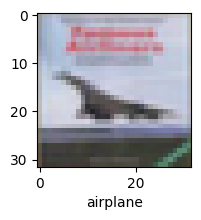

In [ ]:
plot_sample(X_test, y_test,3)
